# STG and LSPIN Evaluation Notebook

This notebook runs the iterative feature-reduction experiment across the six loaded datasets:
- Breast, defined as "hard" dataset
- madelon, defined as "hard" dataset
- SMK-CAN-187, defined as "medium" dataset
- colon, defined as "medium" dataset
- leukemia, defined as "easy" dataset
- RELATHE, defined as "easy" dataset

## Workflow
1. Initialize notebook environment.
2. Configure paths and load datasets.
3. Apply reproducibility settings (seeding).
4. Run STG/LSPIN feature selection + ExtraTrees evaluation in 5-fold CV.
5. Plot and save train/test curves.
6. Write outputs into a dedicated output folder.
7. Re-run safety checks for repeatability.

## Initialize Imports, Libraries, and Global Configuration

In [2]:
%pip install featselectlib lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 11.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=e0ea8be1594f20757e89f04f13ab1c903a8d47cfba935344dc673434a1785b2d
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [3]:
from __future__ import annotations
import collections as _collections
import os
import random
from pathlib import Path
from typing import Any, Dict, Mapping, MutableMapping, Sequence, Tuple
from collections import abc as _collections_abc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy import sparse as sp
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler

for _alias in ("Callable", "Iterable", "Mapping", "MutableMapping", "Sequence", "Set"):
    if not hasattr(_collections, _alias):
        setattr(_collections, _alias, getattr(_collections_abc, _alias))

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive  # type: ignore
    drive.mount("/content/drive", force_remount=False)

PROJECT_DIR_CANDIDATES = [
    Path("/content/drive/MyDrive/Colab Notebooks/Thesis"),
    Path.cwd(),
]
BASE_DIR = next((p for p in PROJECT_DIR_CANDIDATES if p.exists()), Path.cwd())
os.chdir(BASE_DIR)

try:
    from featselectlib.supervised_feature_selection.Lspin import DataSetMeta, Lspin
    from featselectlib.supervised_feature_selection.stg.python.stg import STG
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Missing dependency 'featselectlib'. Install it first (for example in Colab: !pip install featselectlib)."
    ) from exc

DEFAULT_DATASET_NAMES = ("Breast", "madelon", "SMK-CAN-187", "colon", "leukemia", "RELATHE")
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Environment: {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Base directory: {BASE_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Torch device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Mounted at /content/drive
Environment: Google Colab
Base directory: /content/drive/MyDrive/Colab Notebooks/Thesis
Output directory: /content/drive/MyDrive/Colab Notebooks/Thesis/output
Torch device: cpu


## Dataset Paths from Local Data Folder

This section resolves dataset paths for both local runs and Google Colab/Drive runs, reports which required datasets exist, and loads available `.mat` files into memory.

In [4]:
data_root_candidates = [
    BASE_DIR.parent / "data",
    Path(r"c:/Users/shlom/Thesis/data"),
    Path("/content/drive/MyDrive/Colab Notebooks/Thesis/data"),
    Path("/content/drive/Othercomputers/המחשב האישי שלי/Thesis/data"),
]
DATA_ROOT = next((p for p in data_root_candidates if p.exists()), data_root_candidates[0])
print(f"Data root: {DATA_ROOT}")
DATASET_PATHS = {
    "Breast": DATA_ROOT / "Challenging Data Collections" / "Unaltered Data Sources" / "Breast.mat",
    "madelon": DATA_ROOT / "Challenging Data Collections" / "Unaltered Data Sources" / "madelon.mat",
    "SMK-CAN-187": DATA_ROOT / "Standard Difficulty Data Collections" / "scikit-feature" /  "SMK-CAN-187.mat",
    "colon": DATA_ROOT / "Standard Difficulty Data Collections" / "scikit-feature" /  "colon.mat",
    "leukemia": DATA_ROOT / "Standard Difficulty Data Collections" / "scikit-feature" /  "leukemia.mat",
    "RELATHE": DATA_ROOT / "Standard Difficulty Data Collections" / "scikit-feature" / "RELATHE.mat",
}

path_status_df = pd.DataFrame(
    [{"dataset": name, "path": str(path), "exists": path.exists()} for name, path in DATASET_PATHS.items()]
)
display(path_status_df)

Data root: /content/drive/MyDrive/Colab Notebooks/Thesis/data


,dataset,path,exists
0,Breast,/content/drive/MyDrive/Colab Notebooks/Thesis/...,True
1,madelon,/content/drive/MyDrive/Colab Notebooks/Thesis/...,True
2,SMK-CAN-187,/content/drive/MyDrive/Colab Notebooks/Thesis/...,True
3,colon,/content/drive/MyDrive/Colab Notebooks/Thesis/...,True
4,leukemia,/content/drive/MyDrive/Colab Notebooks/Thesis/...,True
5,RELATHE,/content/drive/MyDrive/Colab Notebooks/Thesis/...,True


## Check and Report Dataset File Paths

In [5]:
from scipy.io import loadmat


def _load_mat_xy(mat_path: Path) -> tuple[np.ndarray, np.ndarray]:
    mat = loadmat(mat_path)

    feature_keys = ("X", "x", "data", "features", "fea")
    label_keys = ("y", "Y", "labels", "label", "target", "gnd")

    X = next((mat[k] for k in feature_keys if k in mat), None)
    y = next((mat[k] for k in label_keys if k in mat), None)

    if X is None or y is None:
        raise KeyError(f"Could not find feature/label keys in {mat_path.name}")

    X = np.asarray(X)
    y = np.asarray(y).reshape(-1)
    return X, y


def _load_dataset_xy(path: Path) -> tuple[np.ndarray, np.ndarray]:
    if path.suffix.lower() != ".mat":
        raise ValueError(f"Unsupported dataset format: {path.name}. Only .mat files are supported.")
    return _load_mat_xy(path)


loaded_from_data_folder = {}
missing_from_data_folder = []

for dataset_name, dataset_path in DATASET_PATHS.items():
    if dataset_path.exists():
        X, y = _load_dataset_xy(dataset_path)
        globals()[dataset_name] = (X, y)
        loaded_from_data_folder[dataset_name] = {"shape": X.shape, "labels": np.unique(y).size}
    else:
        missing_from_data_folder.append(dataset_name)

print("Loaded datasets from data folder:")
for name, meta in loaded_from_data_folder.items():
    print(f"- {name}: X shape={meta['shape']}, #classes={meta['labels']}")

if missing_from_data_folder:
    print("\nMissing datasets in data folder:", ", ".join(missing_from_data_folder))

Loaded datasets from data folder:
- Breast: X shape=(97, 24481), #classes=2
- madelon: X shape=(2600, 500), #classes=2
- SMK-CAN-187: X shape=(187, 19993), #classes=2
- colon: X shape=(62, 2000), #classes=2
- leukemia: X shape=(72, 7070), #classes=2
- RELATHE: X shape=(1427, 4322), #classes=2


## Define Functions to Load .mat File Format

In [6]:
def set_global_seed(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_global_seed(SEED)
print("Global seed configured:", SEED)

Global seed configured: 42


## Define Feature Selection and Evaluation Pipeline
The following cells define modular functions for baseline ExtraTrees, STG, and LSPIN with 5-fold CV across iterative feature ratios: 100%, 90%, 80%, ..., 10%, and 5%.

In [7]:
def _as_numpy_array(value: Any) -> np.ndarray:
    if sp.issparse(value):
        return value.toarray()
    if hasattr(value, "to_numpy"):
        return value.to_numpy()
    return np.asarray(value)


def extract_xy(dataset: Any) -> Tuple[np.ndarray, np.ndarray]:
    if isinstance(dataset, (tuple, list)):
        if len(dataset) != 2:
            raise ValueError("Dataset tuple/list must have exactly (X, y).")
        return _as_numpy_array(dataset[0]), np.asarray(dataset[1])

    if isinstance(dataset, Mapping):
        feature_keys = ("X", "x", "data", "features")
        label_keys = ("y", "Y", "labels", "target", "targets")
        X = next((dataset[k] for k in feature_keys if k in dataset), None)
        y = next((dataset[k] for k in label_keys if k in dataset), None)
        if X is None or y is None:
            raise ValueError("Dataset mapping must include feature and label entries.")
        return _as_numpy_array(X), np.asarray(y)

    for feature_attr, label_attr in (("data", "target"), ("X", "y"), ("features", "labels")):
        if hasattr(dataset, feature_attr) and hasattr(dataset, label_attr):
            return _as_numpy_array(getattr(dataset, feature_attr)), np.asarray(getattr(dataset, label_attr))

    raise TypeError("Unsupported dataset format.")


def encode_labels(y: np.ndarray) -> Tuple[np.ndarray, LabelEncoder]:
    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(np.asarray(y).ravel())
    return y_encoded, encoder


def prepare_fold_arrays(X_train: np.ndarray, X_test: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    scaler = StandardScaler(with_mean=not sp.issparse(X_train))
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    if sp.issparse(X_train_scaled):
        X_train_scaled = X_train_scaled.toarray()
    if sp.issparse(X_test_scaled):
        X_test_scaled = X_test_scaled.toarray()

    return np.asarray(X_train_scaled, dtype=np.float32), np.asarray(X_test_scaled, dtype=np.float32)


def compute_auc(y_true: np.ndarray, y_proba: np.ndarray) -> float:
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    if y_proba.ndim == 1 or y_proba.shape[1] == 1:
        return float(roc_auc_score(y_true, y_proba.ravel()))
    if y_proba.shape[1] == 2:
        return float(roc_auc_score(y_true, y_proba[:, 1]))
    return float(roc_auc_score(y_true, y_proba, multi_class="ovr", average="weighted"))


def fit_extra_trees(
    X_train: np.ndarray,
    y_train: np.ndarray,
    random_state: int,
    n_estimators: int = 200,
    max_depth: int | None = 4,
    min_samples_leaf: int = 1,
    max_features: str | float | int | None = "sqrt",
) -> ExtraTreesClassifier:
    clf = ExtraTreesClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=random_state,
        class_weight="balanced",
        n_jobs=-1,
    )
    clf.fit(X_train, y_train)
    return clf


def evaluate_classifier(clf: ExtraTreesClassifier, X_test: np.ndarray, y_test: np.ndarray) -> Dict[str, float]:
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)
    return {
        "auc": compute_auc(y_test, y_proba),
        "accuracy": float(accuracy_score(y_test, y_pred)),
    }


def build_feature_ratios() -> list[float]:
    # 100%, then cut 10% each step, and add final 5% iteration.
    ratios = [1.0] + [round(v, 2) for v in np.arange(0.9, 0.0, -0.1)] + [0.05]
    return sorted(set(ratios), reverse=True)


def ratio_to_k(p: int, ratio: float) -> int:
    return max(1, int(round(ratio * p)))


def extract_stg_top_k_features(selector: STG, k: int) -> np.ndarray:
    gate_values = np.asarray(selector.get_gates("prob"), dtype=np.float32).reshape(-1)
    ranked_indices = np.argsort(gate_values)[-k:][::-1]
    return ranked_indices


def extract_lspin_top_k_features(model: Lspin, X_train: np.ndarray, k: int) -> np.ndarray:
    gate_matrix = model.get_prob_alpha(torch.as_tensor(X_train, dtype=torch.float32, device=model.device))
    gate_matrix = gate_matrix.detach().cpu().numpy()
    if gate_matrix.ndim == 1:
        global_scores = gate_matrix.reshape(-1)
    else:
        global_scores = gate_matrix.mean(axis=0)
    ranked_indices = np.argsort(global_scores)[-k:][::-1]
    return ranked_indices


def fit_stg_selector(
    X_train: np.ndarray,
    y_train: np.ndarray,
    k: int,
    random_state: int,
    epochs: int = 50,
    learning_rate: float = 1e-4,
    hidden_dims: Sequence[int] = (128, 64),
    sigma: float = 0.5,
    lam: float = 0.1,
    batch_size: int = 64,
    optimizer: str = "SGD",
    activation: str = "tanh",
    early_stopping_patience: int = 25,
    early_stopping_min_delta: float = 1e-4,
    early_stopping_min_epochs: int = 50,
) -> Tuple[np.ndarray, list[float]]:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    n_features = X_train.shape[1]
    n_classes = len(np.unique(y_train))

    selector = STG(
        device=device,
        input_dim=n_features,
        output_dim=n_classes,
        hidden_dims=list(hidden_dims),
        activation=activation,
        sigma=sigma,
        lam=lam,
        optimizer=optimizer,
        learning_rate=learning_rate,
        batch_size=batch_size,
        task_type="classification",
        random_state=random_state,
    )
    train_loader = selector.get_dataloader(X_train, y_train, shuffle=True)
    train_losses = []
    best_loss = float("inf")
    bad_epochs = 0

    for epoch_index in range(epochs):
        epoch_meters = selector.train_epoch(train_loader)
        epoch_loss = None
        if hasattr(epoch_meters, "avg") and epoch_meters.avg is not None:
            epoch_loss = epoch_meters.avg.get("loss")
        if epoch_loss is not None:
            current_loss = float(epoch_loss)
            train_losses.append(current_loss)
            if current_loss < best_loss - early_stopping_min_delta:
                best_loss = current_loss
                bad_epochs = 0
            else:
                bad_epochs += 1
            if (epoch_index + 1) >= early_stopping_min_epochs and bad_epochs >= early_stopping_patience:
                print(f"STG early stopping at epoch {epoch_index + 1} (best loss={best_loss:.6f})")
                break

    return extract_stg_top_k_features(selector, k), train_losses


def fit_lspin_selector(
    X_train: np.ndarray,
    y_train: np.ndarray,
    k: int,
    random_state: int,
    epochs: int = 50,
    learning_rate: float = 0.1,
    hidden_layers: Sequence[int] = (128, 64),
    gating_hidden_layers: Sequence[int] = (64,),
    sigma: float = 0.5,
    lam: float = 0.5,
    batch_size: int = 64,
    batch_normalization: bool = True,
    activation_gating: str = "tanh",
    activation_pred: str = "tanh",
    optimizer: str = "SGD",
    early_stopping_patience: int = 25,
    early_stopping_min_delta: float = 1e-4,
    early_stopping_min_epochs: int = 50,
    **_: Any,
) -> Tuple[np.ndarray, list[float]]:
    n_features = X_train.shape[1]
    labels = np.asarray(y_train).ravel()
    classes = np.unique(labels)
    class_to_index = {label: idx for idx, label in enumerate(classes)}
    y_index = np.array([class_to_index[label] for label in labels], dtype=np.int64)
    y_one_hot = np.eye(len(classes), dtype=np.float32)[y_index]
    metadata = np.zeros((X_train.shape[0], 1), dtype=np.float32)

    train_dataset = DataSetMeta(np.asarray(X_train, dtype=np.float32), y_one_hot, metadata)

    model = Lspin(
        input_node=n_features,
        hidden_layers_node=list(hidden_layers),
        output_node=len(classes),
        gating_net_hidden_layers_node=list(gating_hidden_layers),
        display_step=epochs + 1,
        activation_gating=activation_gating,
        activation_pred=activation_pred,
        feature_selection=True,
        batch_normalization=batch_normalization,
        sigma=sigma,
        lam=lam,
        seed=random_state,
        val=False,
    )
    # Note: 'optimizer' is accepted for compatibility with lspin_params but not used
    # because train_model() controls optimization internally in this API.
    train_losses = []
    best_loss = float("inf")
    bad_epochs = 0

    for epoch_index in range(epochs):
        epoch_losses, _, _ = model.train_model(
            train_dataset,
            batch_size=batch_size,
            num_epoch=1,
            lr=learning_rate,
            compute_sim=False,
        )
        epoch_loss = epoch_losses[-1] if epoch_losses else None
        if epoch_loss is None:
            continue

        current_loss = float(epoch_loss)
        train_losses.append(current_loss)
        if current_loss < best_loss - early_stopping_min_delta:
            best_loss = current_loss
            bad_epochs = 0
        else:
            bad_epochs += 1
        if (epoch_index + 1) >= early_stopping_min_epochs and bad_epochs >= early_stopping_patience:
            print(f"LSPIN early stopping at epoch {epoch_index + 1} (best loss={best_loss:.6f})")
            break
    return extract_lspin_top_k_features(model, X_train, k), [float(value) for value in train_losses]


def expand_loss_histories(fold_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for row in fold_df.itertuples(index=False):
        stg_losses = list(getattr(row, "stg_train_loss_history", []) or [])
        lspin_losses = list(getattr(row, "lspin_train_loss_history", []) or [])

        for epoch_index, loss_value in enumerate(stg_losses, start=1):
            rows.append(
                {
                    "dataset": row.dataset,
                    "fold": int(row.fold),
                    "algorithm": "STG",
                    "epoch": epoch_index,
                    "train_loss": float(loss_value),
                    "feature_ratio": float(row.feature_ratio),
                    "feature_pct": float(row.feature_pct),
                }
            )

        for epoch_index, loss_value in enumerate(lspin_losses, start=1):
            rows.append(
                {
                    "dataset": row.dataset,
                    "fold": int(row.fold),
                    "algorithm": "LSPIN",
                    "epoch": epoch_index,
                    "train_loss": float(loss_value),
                    "feature_ratio": float(row.feature_ratio),
                    "feature_pct": float(row.feature_pct),
                }
            )

    return pd.DataFrame(rows)


def get_checkpoint_path(dataset_name: str) -> Path:
    return OUTPUT_DIR / f"checkpoint_{dataset_name}.pkl"


def load_checkpoint(dataset_name: str) -> pd.DataFrame:
    checkpoint_path = get_checkpoint_path(dataset_name)
    if checkpoint_path.exists():
        return pd.read_pickle(checkpoint_path)
    return pd.DataFrame()


def save_checkpoint(dataset_name: str, fold_df: pd.DataFrame) -> None:
    checkpoint_path = get_checkpoint_path(dataset_name)
    fold_df.to_pickle(checkpoint_path)


def checkpoint_key(dataset_name: str, ratio: float, fold_index: int) -> str:
    return f"{dataset_name}|{ratio:.4f}|{fold_index}"


def run_fold_experiment(
    dataset_name: str,
    fold_index: int,
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    k: int,
    ratio: float,
    random_state: int,
    stg_params: Mapping[str, Any],
    lspin_params: Mapping[str, Any],
    etree_params: Mapping[str, Any],
) -> Dict[str, Any]:
    X_train_scaled, X_test_scaled = prepare_fold_arrays(X_train, X_test)

    baseline_model = fit_extra_trees(X_train_scaled, y_train, random_state=random_state, **dict(etree_params))
    baseline_train_metrics = evaluate_classifier(baseline_model, X_train_scaled, y_train)
    baseline_metrics = evaluate_classifier(baseline_model, X_test_scaled, y_test)

    stg_features, stg_train_loss_history = fit_stg_selector(X_train_scaled, y_train, k=k, random_state=random_state, **dict(stg_params))
    stg_model = fit_extra_trees(X_train_scaled[:, stg_features], y_train, random_state=random_state, **dict(etree_params))
    stg_train_metrics = evaluate_classifier(stg_model, X_train_scaled[:, stg_features], y_train)
    stg_metrics = evaluate_classifier(stg_model, X_test_scaled[:, stg_features], y_test)
    
    if lspin_params.get("batch_size", 64) == -1:
        #create a copy of lspin_params to avoid mutating the original dictionary
        lspin_params = dict(lspin_params)
        lspin_params["batch_size"] = X_train_scaled.shape[0]
    lspin_features, lspin_train_loss_history = fit_lspin_selector(X_train_scaled, y_train, k=k, random_state=random_state, **dict(lspin_params))
    lspin_model = fit_extra_trees(X_train_scaled[:, lspin_features], y_train, random_state=random_state, **dict(etree_params))
    lspin_train_metrics = evaluate_classifier(lspin_model, X_train_scaled[:, lspin_features], y_train)
    lspin_metrics = evaluate_classifier(lspin_model, X_test_scaled[:, lspin_features], y_test)

    return {
        "dataset": dataset_name,
        "fold": fold_index,
        "p": X_train_scaled.shape[1],
        "k": k,
        "feature_ratio": ratio,
        "feature_pct": round(100.0 * ratio, 1),
        "baseline_train_auc": baseline_train_metrics["auc"],
        "baseline_train_accuracy": baseline_train_metrics["accuracy"],
        "baseline_auc": baseline_metrics["auc"],
        "baseline_accuracy": baseline_metrics["accuracy"],
        "stg_train_auc": stg_train_metrics["auc"],
        "stg_train_accuracy": stg_train_metrics["accuracy"],
        "stg_auc": stg_metrics["auc"],
        "stg_accuracy": stg_metrics["accuracy"],
        "stg_train_loss_history": stg_train_loss_history,
        "lspin_train_auc": lspin_train_metrics["auc"],
        "lspin_train_accuracy": lspin_train_metrics["accuracy"],
        "lspin_auc": lspin_metrics["auc"],
        "lspin_accuracy": lspin_metrics["accuracy"],
        "lspin_train_loss_history": lspin_train_loss_history,
        "stg_auc_delta": stg_metrics["auc"] - baseline_metrics["auc"],
        "lspin_auc_delta": lspin_metrics["auc"] - baseline_metrics["auc"],
        "stg_accuracy_delta": stg_metrics["accuracy"] - baseline_metrics["accuracy"],
        "lspin_accuracy_delta": lspin_metrics["accuracy"] - baseline_metrics["accuracy"],
    }


def summarize_fold_results(fold_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (dataset_name, p, ratio, feature_pct, k), part in fold_df.groupby(["dataset", "p", "feature_ratio", "feature_pct", "k"], as_index=False):
        rows.append(
            {
                "dataset": dataset_name,
                "p": int(p),
                "k": int(k),
                "feature_ratio": float(ratio),
                "feature_pct": float(feature_pct),
                "baseline_train_auc_mean": part["baseline_train_auc"].mean(),
                "stg_train_auc_mean": part["stg_train_auc"].mean(),
                "lspin_train_auc_mean": part["lspin_train_auc"].mean(),
                "baseline_auc_mean": part["baseline_auc"].mean(),
                "stg_auc_mean": part["stg_auc"].mean(),
                "lspin_auc_mean": part["lspin_auc"].mean(),
                "stg_auc_delta_mean": part["stg_auc_delta"].mean(),
                "lspin_auc_delta_mean": part["lspin_auc_delta"].mean(),
                "baseline_train_accuracy_mean": part["baseline_train_accuracy"].mean(),
                "stg_train_accuracy_mean": part["stg_train_accuracy"].mean(),
                "lspin_train_accuracy_mean": part["lspin_train_accuracy"].mean(),
                "baseline_accuracy_mean": part["baseline_accuracy"].mean(),
                "stg_accuracy_mean": part["stg_accuracy"].mean(),
                "lspin_accuracy_mean": part["lspin_accuracy"].mean(),
                "stg_accuracy_delta_mean": part["stg_accuracy_delta"].mean(),
                "lspin_accuracy_delta_mean": part["lspin_accuracy_delta"].mean(),
            }
        )
    summary_df = pd.DataFrame(rows).sort_values(["dataset", "feature_ratio"], ascending=[True, False]).reset_index(drop=True)
    return summary_df


def run_dataset_experiment(
    dataset_name: str,
    dataset: Any,
    random_state: int = 42,
    n_splits: int = 5,
    stg_params: Mapping[str, Any] | None = None,
    lspin_params: Mapping[str, Any] | None = None,
    etree_params: Mapping[str, Any] | None = None,
    feature_ratios: Sequence[float] | None = None,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    set_global_seed(random_state)
    stg_params = dict(stg_params or {})
    lspin_params = dict(lspin_params or {})
    etree_params = dict(etree_params or {})

    X, y = extract_xy(dataset)
    y_encoded, _ = encode_labels(y)

    p = X.shape[1]
    feature_ratios = list(feature_ratios or build_feature_ratios())

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_rows = []
    checkpoint_df = load_checkpoint(dataset_name)
    required_checkpoint_cols = {
        "baseline_train_auc", "baseline_train_accuracy",
        "stg_train_auc", "stg_train_accuracy",
        "lspin_train_auc", "lspin_train_accuracy",
    }
    if not checkpoint_df.empty and not required_checkpoint_cols.issubset(checkpoint_df.columns):
        print(f"Checkpoint for {dataset_name} is missing train metrics. Rebuilding it from scratch.")
        checkpoint_df = pd.DataFrame()
    completed_keys = set()
    if not checkpoint_df.empty and {"dataset", "feature_ratio", "fold"}.issubset(checkpoint_df.columns):
        completed_keys = {checkpoint_key(row.dataset, float(row.feature_ratio), int(row.fold)) for row in checkpoint_df.itertuples(index=False)}
        fold_rows.extend(checkpoint_df.to_dict(orient="records"))
        print(f"Resuming {dataset_name} from {len(completed_keys)} completed fold/ratio jobs")

    for ratio in feature_ratios:
        k = ratio_to_k(p, ratio)
        for fold_index, (train_idx, test_idx) in enumerate(cv.split(X, y_encoded), start=1):
            current_key = checkpoint_key(dataset_name, ratio, fold_index)
            if current_key in completed_keys:
                continue
            fold_rows.append(
                run_fold_experiment(
                    dataset_name=dataset_name,
                    fold_index=fold_index,
                    X_train=X[train_idx],
                    X_test=X[test_idx],
                    y_train=y_encoded[train_idx],
                    y_test=y_encoded[test_idx],
                    k=k,
                    ratio=ratio,
                    random_state=random_state + fold_index,
                    stg_params=stg_params,
                    lspin_params=lspin_params,
                    etree_params=etree_params,
                )
            )
            save_checkpoint(dataset_name, pd.DataFrame(fold_rows))

    fold_df = pd.DataFrame(fold_rows)
    loss_history_df = expand_loss_histories(fold_df)
    summary_df = summarize_fold_results(fold_df)
    return summary_df, fold_df, loss_history_df


def collect_loaded_datasets(namespace: MutableMapping[str, Any] | None = None, allow_partial: bool = True) -> Dict[str, Any]:
    namespace = globals() if namespace is None else namespace
    available = {name: namespace[name] for name in DEFAULT_DATASET_NAMES if name in namespace}
    missing = [name for name in DEFAULT_DATASET_NAMES if name not in namespace]

    if missing and not allow_partial:
        raise KeyError(f"Missing dataset variables: {', '.join(missing)}")

    if missing:
        print("Skipping missing datasets:", ", ".join(missing))
    return available

## Helper Function to Collect Loaded Datasets

In [ ]:
def get_hyperparameters(dataset_name, X_train):
    """
    Return hyperparameters for STG, LSPIN, and ExtraTrees based on dataset group.
    """
    name = str(dataset_name).strip().lower()
    full_batch = len(X_train)

    # Group 1: Extreme Low Sample Size (LSS)
    lss_datasets = {"breast", "colon", "leukemia", "smk-can-187"}

    # Group 2: Medium-Large datasets
    med_large_datasets = {"madelon", "relathe"}

    if name in lss_datasets:
        stg_params = {
            "epochs": 200,
            "batch_size": full_batch,
            "learning_rate": 0.5,
            "lam": 1.0,
            "activation": "tanh",
            "optimizer": "SGD",
            "hidden_dims": (128, 64),
            "sigma": 0.5,
        }

        lspin_params = {
            "epochs": 500,
            "batch_size": full_batch,
            "learning_rate": 0.05,
            "lam": 1.0,
            "activation_gating": "tanh",
            "activation_pred": "tanh",
            "optimizer": "SGD",
            "hidden_layers": (100, 50, 30),
            "gating_hidden_layers": (100, 10),
            "sigma": 0.5,
        }

    elif name in med_large_datasets:
        if name == "relathe":
            stg_epochs = 200
            stg_batch_size = 40
        else:  # madelon
            stg_epochs = 1000
            stg_batch_size = 200

        stg_params = {
            "epochs": stg_epochs,
            "batch_size": stg_batch_size,
            "learning_rate": 0.05,
            "lam": 0.1,
            "activation": "tanh",
            "optimizer": "SGD",
            "hidden_dims": (128, 64),
            "sigma": 0.5,
        }

        lspin_params = {
            "epochs": 500,
            "batch_size": full_batch,
            "learning_rate": 0.1,
            "lam": 0.1,
            "activation_gating": "tanh",
            "activation_pred": "tanh",
            "optimizer": "SGD",
            "hidden_layers": (100, 50, 30),
            "gating_hidden_layers": (500,),
            "sigma": 0.5,
        }

    else:
        raise ValueError(
            f"Unknown dataset '{dataset_name}'. "
            "Expected one of: Breast, colon, leukemia, SMK-CAN-187, madelon, RELATHE."
        )

    etree_params = {"n_estimators": 200, "max_depth": 4}
    return stg_params, lspin_params, etree_params

In [9]:
def plot_and_save_loss_curve(
    loss_df: pd.DataFrame,
    dataset_name: str,
    plots_dir: Path,
    title: str | None = None,
    status_prefix: str = "",
) -> None:
    if loss_df.empty:
        print(f"Loss history is missing for {dataset_name}; skipped loss plot.")
        return

    loss_summary = (
        loss_df.groupby(["algorithm", "epoch"], as_index=False)["train_loss"]
        .mean()
        .sort_values(["algorithm", "epoch"])
    )

    fig_loss, ax_loss = plt.subplots(figsize=(10, 5))
    for algorithm_name, algo_part in loss_summary.groupby("algorithm"):
        ax_loss.plot(
            algo_part["epoch"],
            algo_part["train_loss"],
            marker="o",
            linewidth=2,
            label=algorithm_name,
        )

    ax_loss.set_title(title or f"{dataset_name}: Train Loss vs Epoch")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Train loss")
    ax_loss.grid(True, alpha=0.3)
    ax_loss.legend()
    fig_loss.tight_layout()

    loss_plot_path = plots_dir / f"{dataset_name}_train_loss_curve.png"
    fig_loss.savefig(loss_plot_path, dpi=150, bbox_inches="tight")

    if status_prefix:
        print(f"Saved loss plot {status_prefix} {dataset_name}: {loss_plot_path}")
    else:
        print(f"Saved loss plot for {dataset_name}: {loss_plot_path}")

    plt.show()

Feature ratios used: [1.0, np.float64(0.9), np.float64(0.8), np.float64(0.7), np.float64(0.6), np.float64(0.5), np.float64(0.4), np.float64(0.3), np.float64(0.2), np.float64(0.1), 0.05]
Resuming Breast from 55 completed fold/ratio jobs
Saved loss plot right after training Breast: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/Breast_train_loss_curve.png


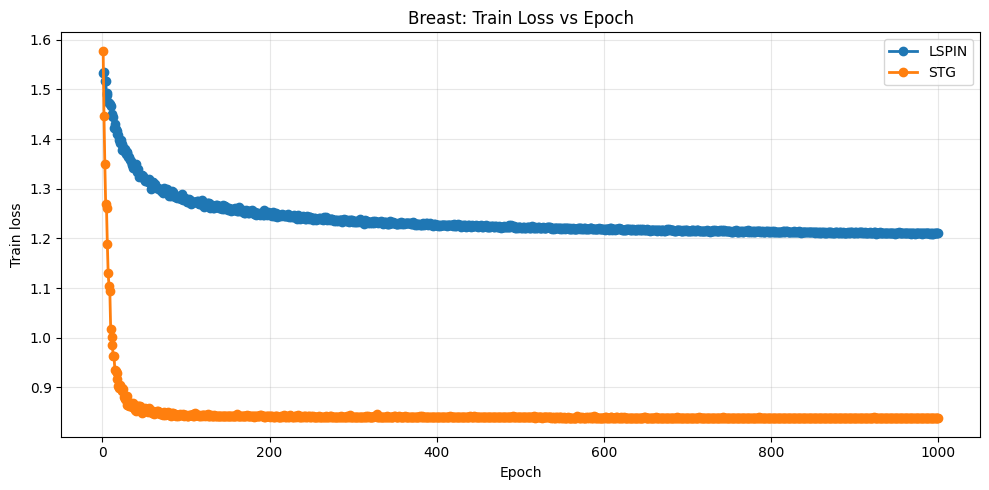


=== Breast summary (first rows) ===


,dataset,p,k,feature_ratio,feature_pct,baseline_train_auc_mean,stg_train_auc_mean,lspin_train_auc_mean,baseline_auc_mean,stg_auc_mean,...,stg_auc_delta_mean,lspin_auc_delta_mean,baseline_train_accuracy_mean,stg_train_accuracy_mean,lspin_train_accuracy_mean,baseline_accuracy_mean,stg_accuracy_mean,lspin_accuracy_mean,stg_accuracy_delta_mean,lspin_accuracy_delta_mean
0,Breast,24481,24481,1.0,100.0,1.0,1.0,1.0,0.765354,0.769960,...,0.004606,-0.007657,1.0,1.0,1.0,0.670526,0.691579,0.690526,0.021053,0.020000
1,Breast,24481,22033,0.9,90.0,1.0,1.0,1.0,0.765354,0.744323,...,-0.021030,-0.025677,1.0,1.0,1.0,0.670526,0.650526,0.680000,-0.020000,0.009474
2,Breast,24481,19585,0.8,80.0,1.0,1.0,1.0,0.765354,0.757495,...,-0.007859,-0.049434,1.0,1.0,1.0,0.670526,0.680526,0.640000,0.010000,-0.030526
3,Breast,24481,17137,0.7,70.0,1.0,1.0,1.0,0.765354,0.740364,...,-0.024990,-0.022566,1.0,1.0,1.0,0.670526,0.650526,0.670000,-0.020000,-0.000526
4,Breast,24481,14689,0.6,60.0,1.0,1.0,1.0,0.765354,0.730646,...,-0.034707,-0.013051,1.0,1.0,1.0,0.670526,0.712632,0.680000,0.042105,0.009474


Resuming madelon from 55 completed fold/ratio jobs
Saved loss plot right after training madelon: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/madelon_train_loss_curve.png


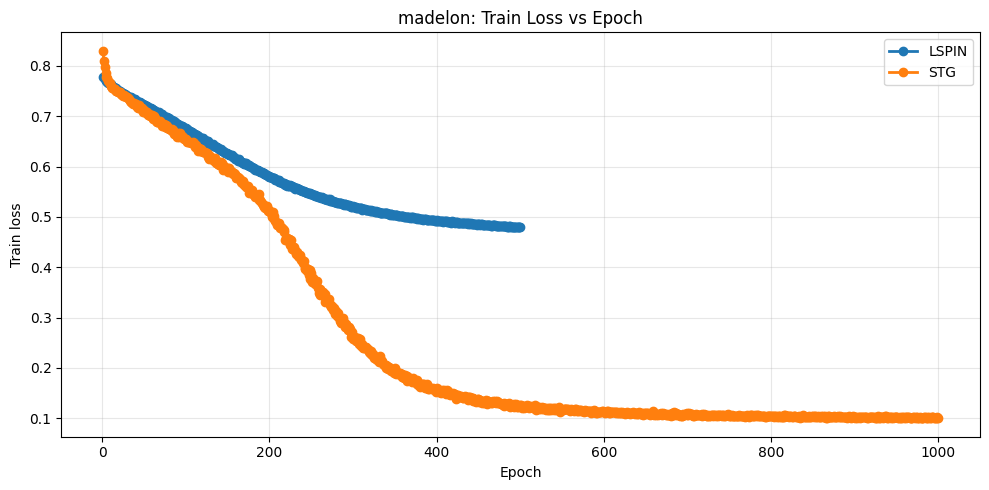


=== madelon summary (first rows) ===


,dataset,p,k,feature_ratio,feature_pct,baseline_train_auc_mean,stg_train_auc_mean,lspin_train_auc_mean,baseline_auc_mean,stg_auc_mean,...,stg_auc_delta_mean,lspin_auc_delta_mean,baseline_train_accuracy_mean,stg_train_accuracy_mean,lspin_train_accuracy_mean,baseline_accuracy_mean,stg_accuracy_mean,lspin_accuracy_mean,stg_accuracy_delta_mean,lspin_accuracy_delta_mean
0,madelon,500,500,1.0,100.0,0.874675,0.869344,0.870169,0.683062,0.679405,...,-0.003657,0.000497,0.762788,0.755481,0.757500,0.619231,0.609231,0.623846,-0.010000,0.004615
1,madelon,500,450,0.9,90.0,0.874675,0.874123,0.867193,0.683062,0.679080,...,-0.003982,-0.000346,0.762788,0.759808,0.747981,0.619231,0.617308,0.622692,-0.001923,0.003462
2,madelon,500,400,0.8,80.0,0.874675,0.865496,0.865549,0.683062,0.686166,...,0.003104,-0.003399,0.762788,0.748269,0.755385,0.619231,0.620000,0.611538,0.000769,-0.007692
3,madelon,500,350,0.7,70.0,0.874675,0.865352,0.871393,0.683062,0.677225,...,-0.005837,-0.005864,0.762788,0.751827,0.765096,0.619231,0.618077,0.622308,-0.001154,0.003077
4,madelon,500,300,0.6,60.0,0.874675,0.855763,0.882642,0.683062,0.671361,...,-0.011701,-0.004982,0.762788,0.734808,0.780385,0.619231,0.623077,0.623077,0.003846,0.003846


Resuming SMK-CAN-187 from 18 completed fold/ratio jobs
Training complete!
Final Training Loss: 1.2130
Training complete!
Final Training Loss: 1.2143
Training complete!
Final Training Loss: 1.2120
Training complete!
Final Training Loss: 1.2127
Training complete!
Final Training Loss: 1.2111
Training complete!
Final Training Loss: 1.2130
Training complete!
Final Training Loss: 1.2143
Training complete!
Final Training Loss: 1.2120
Training complete!
Final Training Loss: 1.2127
Training complete!
Final Training Loss: 1.2111
Training complete!
Final Training Loss: 1.2130
Training complete!
Final Training Loss: 1.2143
Training complete!
Final Training Loss: 1.2120
Training complete!
Final Training Loss: 1.2127
Training complete!
Final Training Loss: 1.2111
Training complete!
Final Training Loss: 1.2130
Training complete!
Final Training Loss: 1.2143
Training complete!
Final Training Loss: 1.2120
Training complete!
Final Training Loss: 1.2127
Training complete!
Final Training Loss: 1.2111
Train

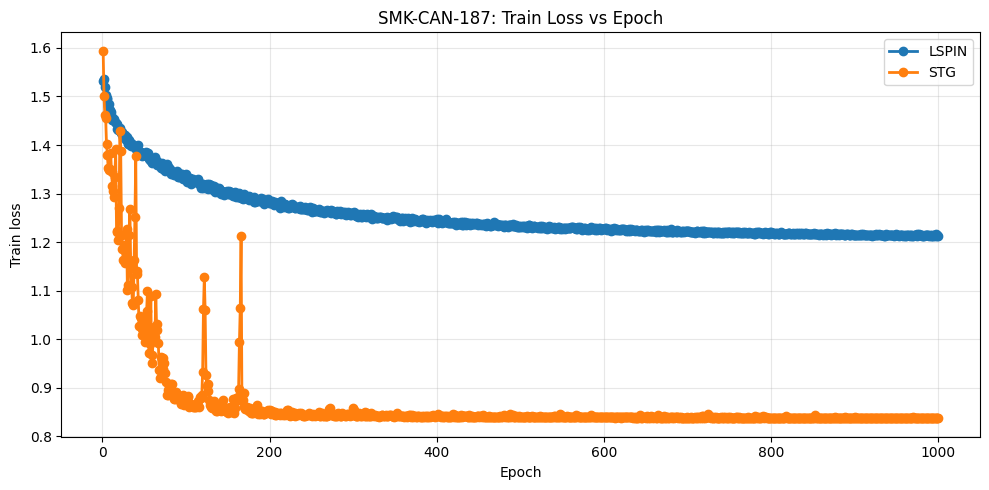


=== SMK-CAN-187 summary (first rows) ===


,dataset,p,k,feature_ratio,feature_pct,baseline_train_auc_mean,stg_train_auc_mean,lspin_train_auc_mean,baseline_auc_mean,stg_auc_mean,...,stg_auc_delta_mean,lspin_auc_delta_mean,baseline_train_accuracy_mean,stg_train_accuracy_mean,lspin_train_accuracy_mean,baseline_accuracy_mean,stg_accuracy_mean,lspin_accuracy_mean,stg_accuracy_delta_mean,lspin_accuracy_delta_mean
0,SMK-CAN-187,19993,19993,1.0,100.0,0.999465,0.999286,0.999642,0.750848,0.748743,...,-0.002105,-0.005906,0.985298,0.987964,0.987973,0.683784,0.694595,0.688905,1.081081e-02,0.005121
1,SMK-CAN-187,19993,17994,0.9,90.0,0.999465,0.999285,0.999427,0.750848,0.748596,...,-0.002251,-0.002573,0.985298,0.987973,0.985298,0.683784,0.683784,0.689331,2.220446e-17,0.005548
2,SMK-CAN-187,19993,15994,0.8,80.0,0.999465,0.999568,0.999465,0.750848,0.746667,...,-0.004181,0.005702,0.985298,0.989298,0.990658,0.683784,0.688905,0.689047,5.120910e-03,0.005263
3,SMK-CAN-187,19993,13995,0.7,70.0,0.999465,0.999394,0.999214,0.750848,0.748947,...,-0.001901,-0.004795,0.985298,0.989315,0.983973,0.683784,0.688905,0.678521,5.120910e-03,-0.005263
4,SMK-CAN-187,19993,11996,0.6,60.0,0.999465,0.999285,0.999286,0.750848,0.751550,...,0.000702,0.013187,0.985298,0.989306,0.985315,0.683784,0.683784,0.689047,2.220446e-17,0.005263


Training complete!
Final Training Loss: 1.2026
Training complete!
Final Training Loss: 1.1967
Training complete!
Final Training Loss: 1.1995
Training complete!
Final Training Loss: 1.1985
Training complete!
Final Training Loss: 1.1991
Training complete!
Final Training Loss: 1.2026
Training complete!
Final Training Loss: 1.1967
Training complete!
Final Training Loss: 1.1995
Training complete!
Final Training Loss: 1.1985
Training complete!
Final Training Loss: 1.1991
Training complete!
Final Training Loss: 1.2026
Training complete!
Final Training Loss: 1.1967
Training complete!
Final Training Loss: 1.1995
Training complete!
Final Training Loss: 1.1985
Training complete!
Final Training Loss: 1.1991
Training complete!
Final Training Loss: 1.2026
Training complete!
Final Training Loss: 1.1967
Training complete!
Final Training Loss: 1.1995
Training complete!
Final Training Loss: 1.1985
Training complete!
Final Training Loss: 1.1991
Training complete!
Final Training Loss: 1.2026
Training comp

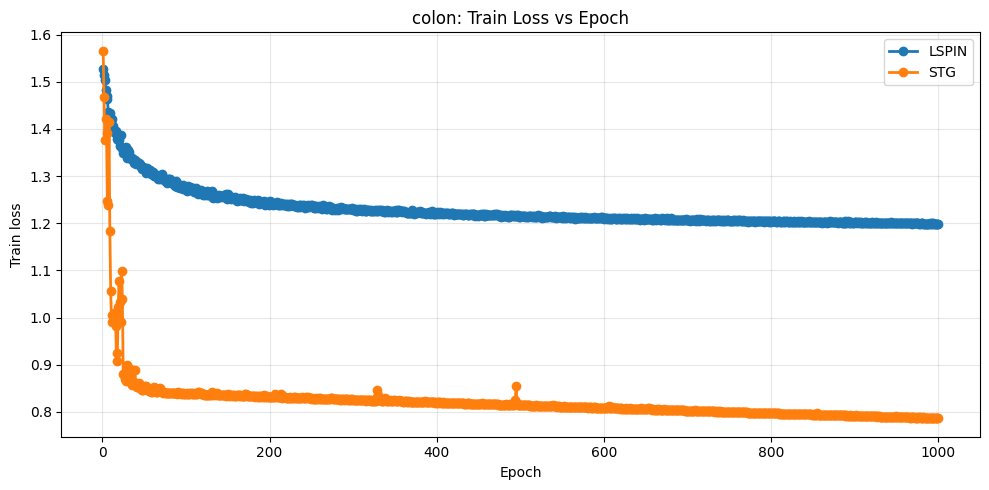


=== colon summary (first rows) ===


,dataset,p,k,feature_ratio,feature_pct,baseline_train_auc_mean,stg_train_auc_mean,lspin_train_auc_mean,baseline_auc_mean,stg_auc_mean,...,stg_auc_delta_mean,lspin_auc_delta_mean,baseline_train_accuracy_mean,stg_train_accuracy_mean,lspin_train_accuracy_mean,baseline_accuracy_mean,stg_accuracy_mean,lspin_accuracy_mean,stg_accuracy_delta_mean,lspin_accuracy_delta_mean
0,colon,2000,2000,1.0,100.0,1.0,1.0,1.0,0.92,0.89625,...,-0.02375,-0.01250,1.0,1.0,1.0,0.853846,0.805128,0.805128,-0.048718,-0.048718
1,colon,2000,1800,0.9,90.0,1.0,1.0,1.0,0.92,0.92500,...,0.00500,-0.02500,1.0,1.0,1.0,0.853846,0.806410,0.820513,-0.047436,-0.033333
2,colon,2000,1600,0.8,80.0,1.0,1.0,1.0,0.92,0.91250,...,-0.00750,0.00375,1.0,1.0,1.0,0.853846,0.837179,0.853846,-0.016667,0.000000
3,colon,2000,1400,0.7,70.0,1.0,1.0,1.0,0.92,0.91250,...,-0.00750,-0.02375,1.0,1.0,1.0,0.853846,0.789744,0.837179,-0.064103,-0.016667
4,colon,2000,1200,0.6,60.0,1.0,1.0,1.0,0.92,0.88375,...,-0.03625,0.00875,1.0,1.0,1.0,0.853846,0.789744,0.838462,-0.064103,-0.015385


Training complete!
Final Training Loss: 1.2071
Training complete!
Final Training Loss: 1.2059
Training complete!
Final Training Loss: 1.2054
Training complete!
Final Training Loss: 1.2065
Training complete!
Final Training Loss: 1.2080
Training complete!
Final Training Loss: 1.2071
Training complete!
Final Training Loss: 1.2059
Training complete!
Final Training Loss: 1.2054
Training complete!
Final Training Loss: 1.2065
Training complete!
Final Training Loss: 1.2080
Training complete!
Final Training Loss: 1.2071
Training complete!
Final Training Loss: 1.2059
Training complete!
Final Training Loss: 1.2054
Training complete!
Final Training Loss: 1.2065
Training complete!
Final Training Loss: 1.2080
Training complete!
Final Training Loss: 1.2071
Training complete!
Final Training Loss: 1.2059
Training complete!
Final Training Loss: 1.2054
Training complete!
Final Training Loss: 1.2065
Training complete!
Final Training Loss: 1.2080
Training complete!
Final Training Loss: 1.2071
Training comp

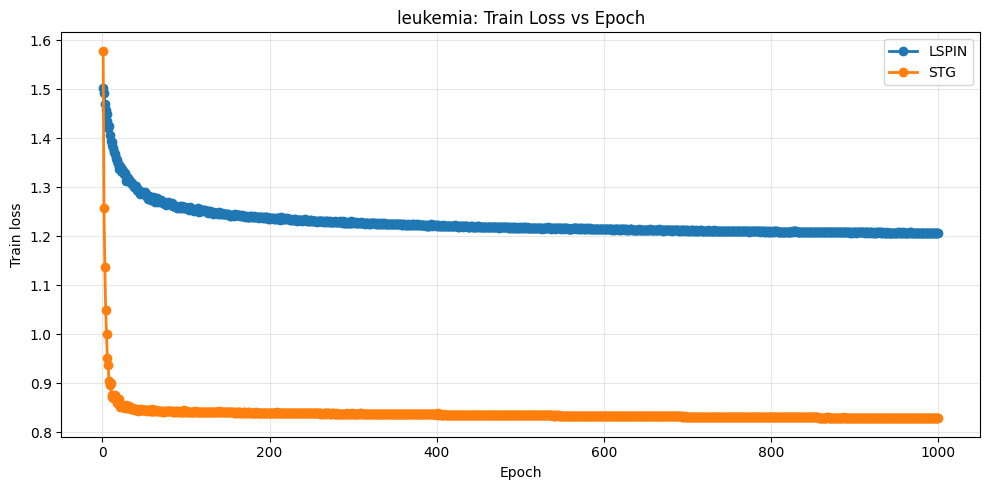


=== leukemia summary (first rows) ===


,dataset,p,k,feature_ratio,feature_pct,baseline_train_auc_mean,stg_train_auc_mean,lspin_train_auc_mean,baseline_auc_mean,stg_auc_mean,...,stg_auc_delta_mean,lspin_auc_delta_mean,baseline_train_accuracy_mean,stg_train_accuracy_mean,lspin_train_accuracy_mean,baseline_accuracy_mean,stg_accuracy_mean,lspin_accuracy_mean,stg_accuracy_delta_mean,lspin_accuracy_delta_mean
0,leukemia,7070,7070,1.0,100.0,1.0,1.0,1.0,0.98,0.980,...,0.000,0.004,1.0,1.0,1.0,0.973333,0.959048,0.931429,-0.014286,-0.041905
1,leukemia,7070,6363,0.9,90.0,1.0,1.0,1.0,0.98,0.984,...,0.004,0.000,1.0,1.0,1.0,0.973333,0.944762,0.959048,-0.028571,-0.014286
2,leukemia,7070,5656,0.8,80.0,1.0,1.0,1.0,0.98,0.980,...,0.000,0.012,1.0,1.0,1.0,0.973333,0.930476,0.944762,-0.042857,-0.028571
3,leukemia,7070,4949,0.7,70.0,1.0,1.0,1.0,0.98,0.988,...,0.008,0.004,1.0,1.0,1.0,0.973333,0.972381,0.958095,-0.000952,-0.015238
4,leukemia,7070,4242,0.6,60.0,1.0,1.0,1.0,0.98,0.980,...,0.000,0.004,1.0,1.0,1.0,0.973333,0.944762,0.916190,-0.028571,-0.057143


Training complete!
Final Training Loss: 0.4622
Training complete!
Final Training Loss: 0.4624
Training complete!
Final Training Loss: 0.4643
Training complete!
Final Training Loss: 0.4625
Training complete!
Final Training Loss: 0.4632
Training complete!
Final Training Loss: 0.4622
Training complete!
Final Training Loss: 0.4624
Training complete!
Final Training Loss: 0.4643
Training complete!
Final Training Loss: 0.4625
Training complete!
Final Training Loss: 0.4632
Training complete!
Final Training Loss: 0.4622
Training complete!
Final Training Loss: 0.4624
Training complete!
Final Training Loss: 0.4643
Training complete!
Final Training Loss: 0.4625
Training complete!
Final Training Loss: 0.4632
Training complete!
Final Training Loss: 0.4622
Training complete!
Final Training Loss: 0.4624
Training complete!
Final Training Loss: 0.4643
Training complete!
Final Training Loss: 0.4625
Training complete!
Final Training Loss: 0.4632
Training complete!
Final Training Loss: 0.4622
Training comp

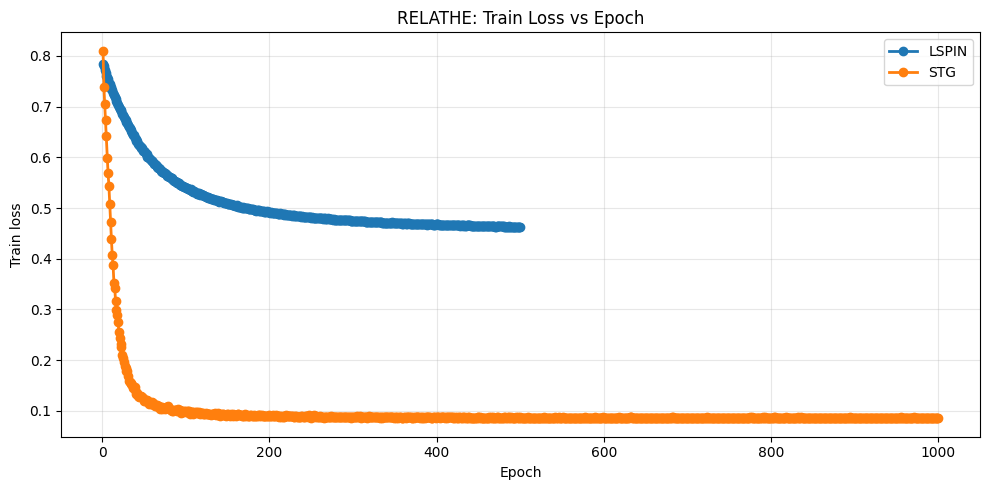


=== RELATHE summary (first rows) ===


,dataset,p,k,feature_ratio,feature_pct,baseline_train_auc_mean,stg_train_auc_mean,lspin_train_auc_mean,baseline_auc_mean,stg_auc_mean,...,stg_auc_delta_mean,lspin_auc_delta_mean,baseline_train_accuracy_mean,stg_train_accuracy_mean,lspin_train_accuracy_mean,baseline_accuracy_mean,stg_accuracy_mean,lspin_accuracy_mean,stg_accuracy_delta_mean,lspin_accuracy_delta_mean
0,RELATHE,4322,4322,1.0,100.0,0.975224,0.976994,0.975563,0.931057,0.928788,...,-0.002269,0.000144,0.887873,0.891904,0.886470,0.838795,0.835301,0.838817,-0.003494,0.000022
1,RELATHE,4322,3890,0.9,90.0,0.975224,0.975576,0.974992,0.931057,0.930143,...,-0.000914,0.002067,0.887873,0.888747,0.888751,0.838795,0.838123,0.839529,-0.000672,0.000734
2,RELATHE,4322,3458,0.8,80.0,0.975224,0.975753,0.975939,0.931057,0.927860,...,-0.003196,0.000645,0.887873,0.884725,0.893655,0.838795,0.836000,0.842309,-0.002795,0.003514
3,RELATHE,4322,3025,0.7,70.0,0.975224,0.977635,0.975085,0.931057,0.933422,...,0.002366,-0.002550,0.887873,0.884368,0.892077,0.838795,0.831113,0.831103,-0.007682,-0.007692
4,RELATHE,4322,2593,0.6,60.0,0.975224,0.975320,0.973529,0.931057,0.930336,...,-0.000721,-0.013117,0.887873,0.879994,0.891021,0.838795,0.831800,0.829729,-0.006995,-0.009066



Combined summary shape: (66, 21)
Combined fold shape: (330, 24)
Combined loss shape: (605000, 7)


,dataset,p,k,feature_ratio,feature_pct,baseline_train_auc_mean,stg_train_auc_mean,lspin_train_auc_mean,baseline_auc_mean,stg_auc_mean,...,stg_auc_delta_mean,lspin_auc_delta_mean,baseline_train_accuracy_mean,stg_train_accuracy_mean,lspin_train_accuracy_mean,baseline_accuracy_mean,stg_accuracy_mean,lspin_accuracy_mean,stg_accuracy_delta_mean,lspin_accuracy_delta_mean
0,Breast,24481,24481,1.0,100.0,1.0,1.0,1.0,0.765354,0.769960,...,0.004606,-0.007657,1.0,1.0,1.0,0.670526,0.691579,0.690526,0.021053,0.020000
1,Breast,24481,22033,0.9,90.0,1.0,1.0,1.0,0.765354,0.744323,...,-0.021030,-0.025677,1.0,1.0,1.0,0.670526,0.650526,0.680000,-0.020000,0.009474
2,Breast,24481,19585,0.8,80.0,1.0,1.0,1.0,0.765354,0.757495,...,-0.007859,-0.049434,1.0,1.0,1.0,0.670526,0.680526,0.640000,0.010000,-0.030526
3,Breast,24481,17137,0.7,70.0,1.0,1.0,1.0,0.765354,0.740364,...,-0.024990,-0.022566,1.0,1.0,1.0,0.670526,0.650526,0.670000,-0.020000,-0.000526
4,Breast,24481,14689,0.6,60.0,1.0,1.0,1.0,0.765354,0.730646,...,-0.034707,-0.013051,1.0,1.0,1.0,0.670526,0.712632,0.680000,0.042105,0.009474
5,Breast,24481,12240,0.5,50.0,1.0,1.0,1.0,0.765354,0.770323,...,0.004970,0.009152,1.0,1.0,1.0,0.670526,0.721579,0.691579,0.051053,0.021053
6,Breast,24481,9792,0.4,40.0,1.0,1.0,1.0,0.765354,0.741475,...,-0.023879,0.011172,1.0,1.0,1.0,0.670526,0.711053,0.702105,0.040526,0.031579
7,Breast,24481,7344,0.3,30.0,1.0,1.0,1.0,0.765354,0.729939,...,-0.035414,-0.024404,1.0,1.0,1.0,0.670526,0.680526,0.649474,0.010000,-0.021053
8,Breast,24481,4896,0.2,20.0,1.0,1.0,1.0,0.765354,0.735939,...,-0.029414,-0.024949,1.0,1.0,1.0,0.670526,0.638947,0.691053,-0.031579,0.020526
9,Breast,24481,2448,0.1,10.0,1.0,1.0,1.0,0.765354,0.763071,...,-0.002283,-0.064889,1.0,1.0,1.0,0.670526,0.701053,0.630526,0.030526,-0.040000


In [10]:
feature_ratios = build_feature_ratios()
print("Feature ratios used:", feature_ratios)

plots_dir = OUTPUT_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

datasets = collect_loaded_datasets(globals(), allow_partial=True)
summary_tables: Dict[str, pd.DataFrame] = {}
fold_tables: Dict[str, pd.DataFrame] = {}
loss_tables: Dict[str, pd.DataFrame] = {}

for dataset_name, dataset in datasets.items():
    X_data, _ = extract_xy(dataset)
    stg_params, lspin_params, etree_params = get_hyperparameters(dataset_name, X_data)

    summary_df, fold_df, loss_df = run_dataset_experiment(
        dataset_name,
        dataset,
        random_state=SEED,
        n_splits=5,
        stg_params=stg_params,
        lspin_params=lspin_params,
        etree_params=etree_params,
        feature_ratios=feature_ratios,
    )
    summary_tables[dataset_name] = summary_df
    fold_tables[dataset_name] = fold_df
    loss_tables[dataset_name] = loss_df

    plot_and_save_loss_curve(
        loss_df=loss_df,
        dataset_name=dataset_name,
        plots_dir=plots_dir,
        title=f"{dataset_name}: Train Loss vs Epoch",
        status_prefix="right after training",
    )

    print(f"\n=== {dataset_name} summary (first rows) ===")
    display(summary_df.head())

combined_summary_df = pd.concat(summary_tables.values(), ignore_index=True)
combined_fold_df = pd.concat(fold_tables.values(), ignore_index=True)
combined_loss_df = pd.concat(loss_tables.values(), ignore_index=True)

print("\nCombined summary shape:", combined_summary_df.shape)
print("Combined fold shape:", combined_fold_df.shape)
print("Combined loss shape:", combined_loss_df.shape)
display(combined_summary_df.head(10))

## Configure Algorithm Parameters and Run Feature Selection Experiments

Saved test plot: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/Breast_test_curves.png


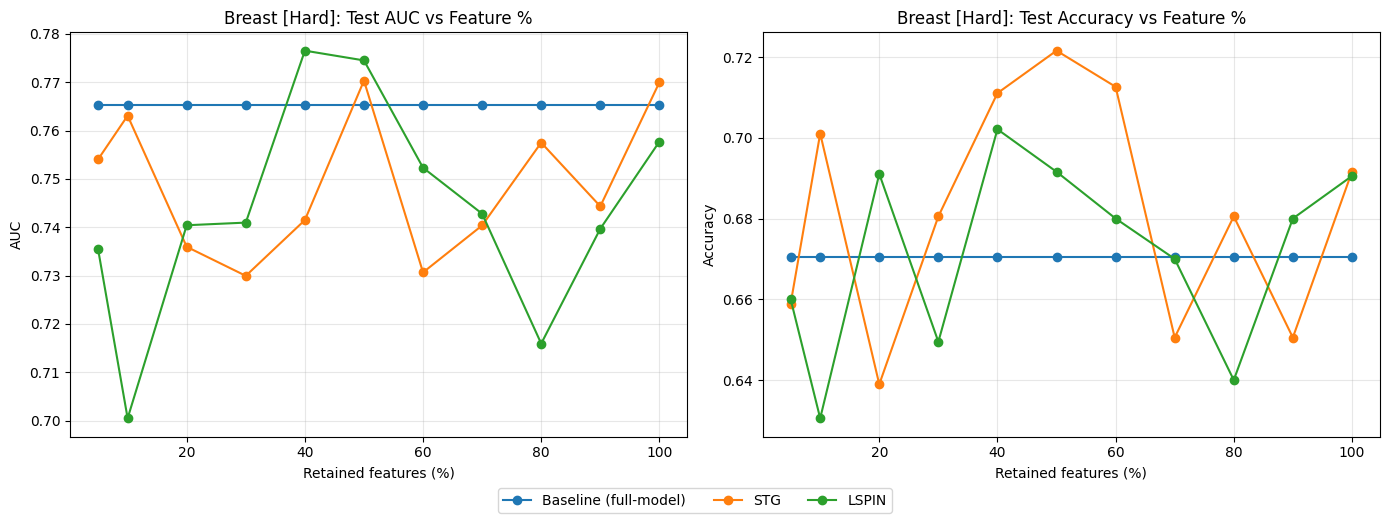

Saved train plot: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/Breast_train_curves.png


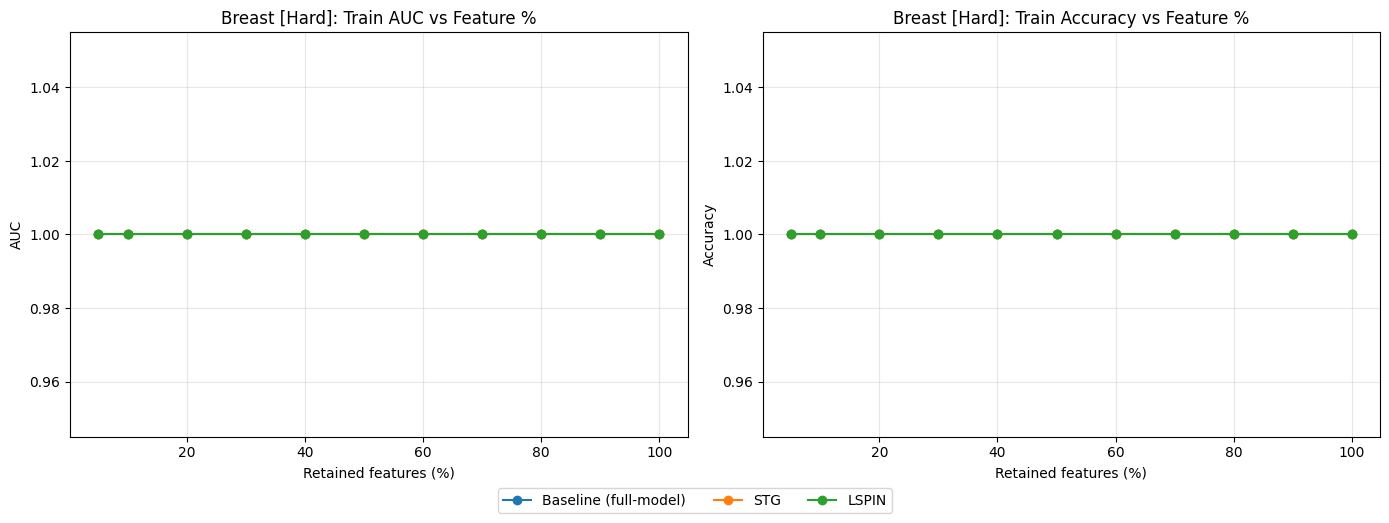

Saved loss plot: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/Breast_train_loss_curve.png


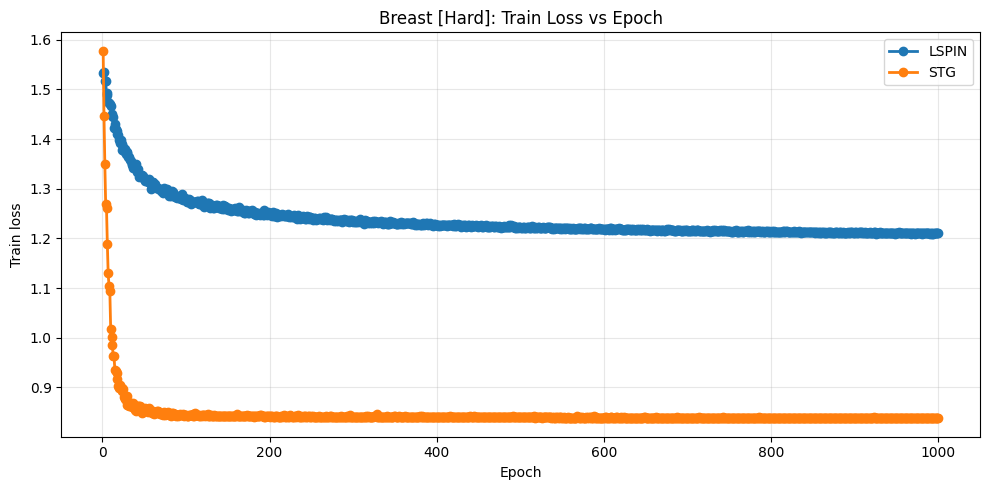

Saved test plot: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/RELATHE_test_curves.png


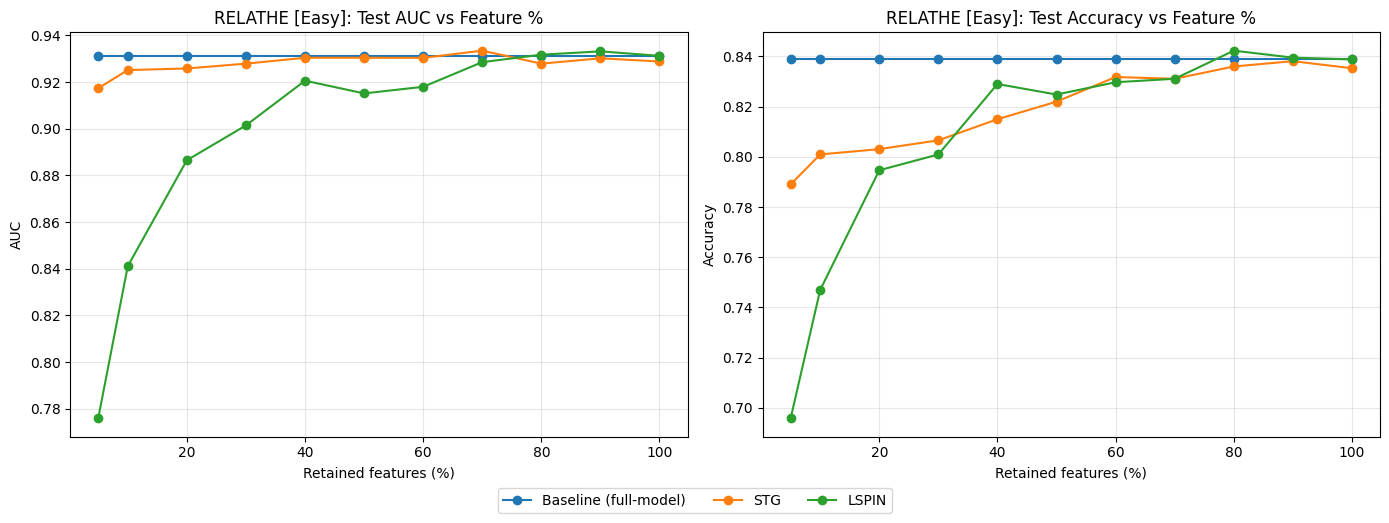

Saved train plot: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/RELATHE_train_curves.png


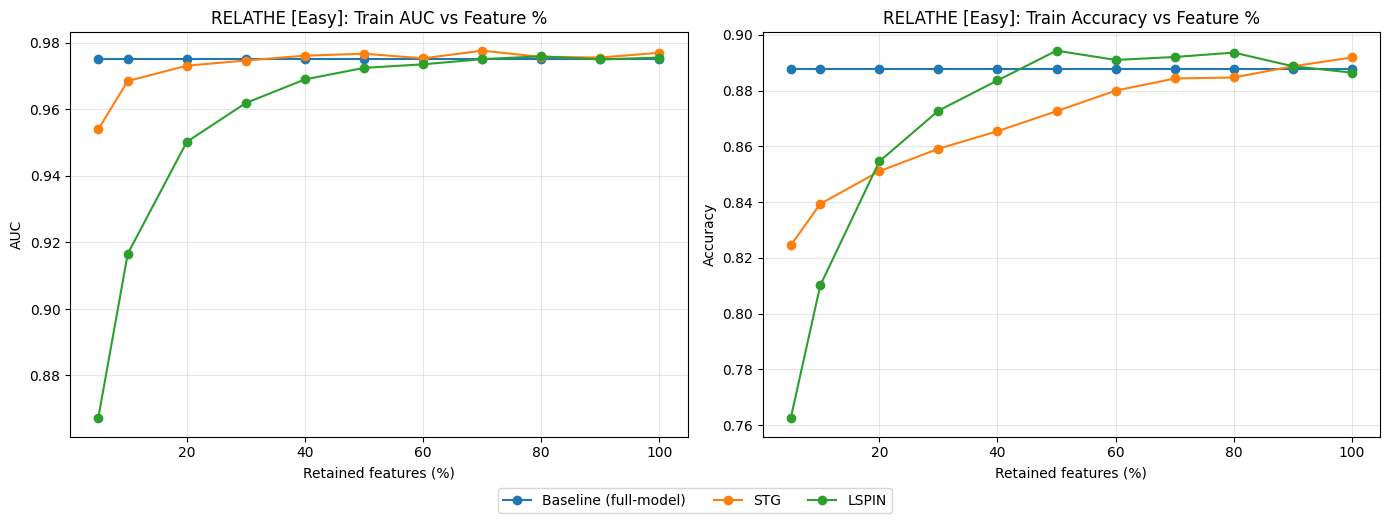

Saved loss plot: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/RELATHE_train_loss_curve.png


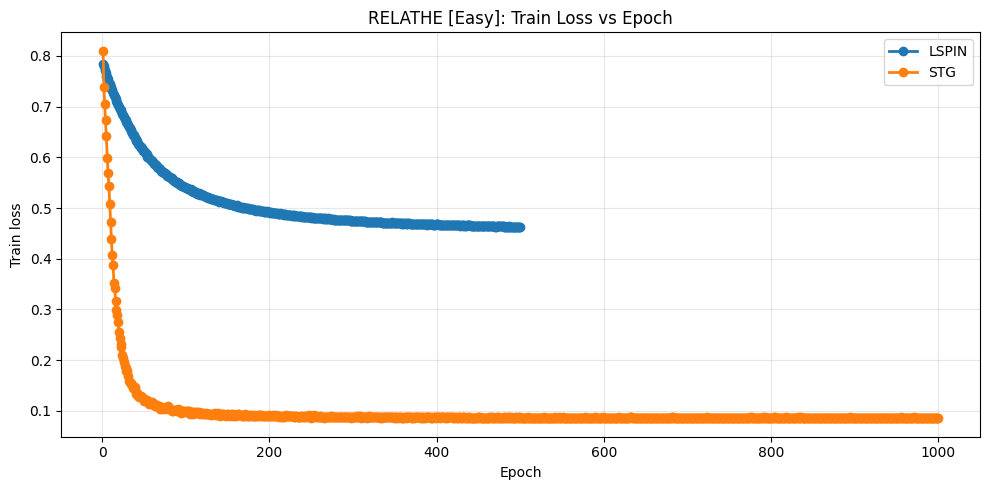

Saved test plot: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/SMK-CAN-187_test_curves.png


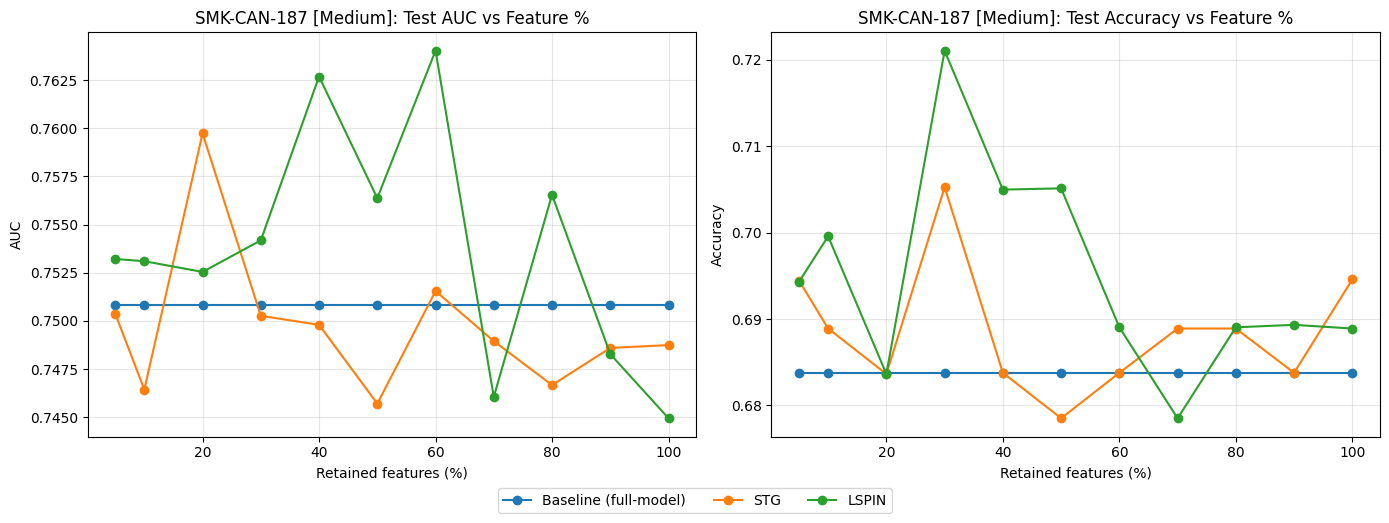

Saved train plot: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/SMK-CAN-187_train_curves.png


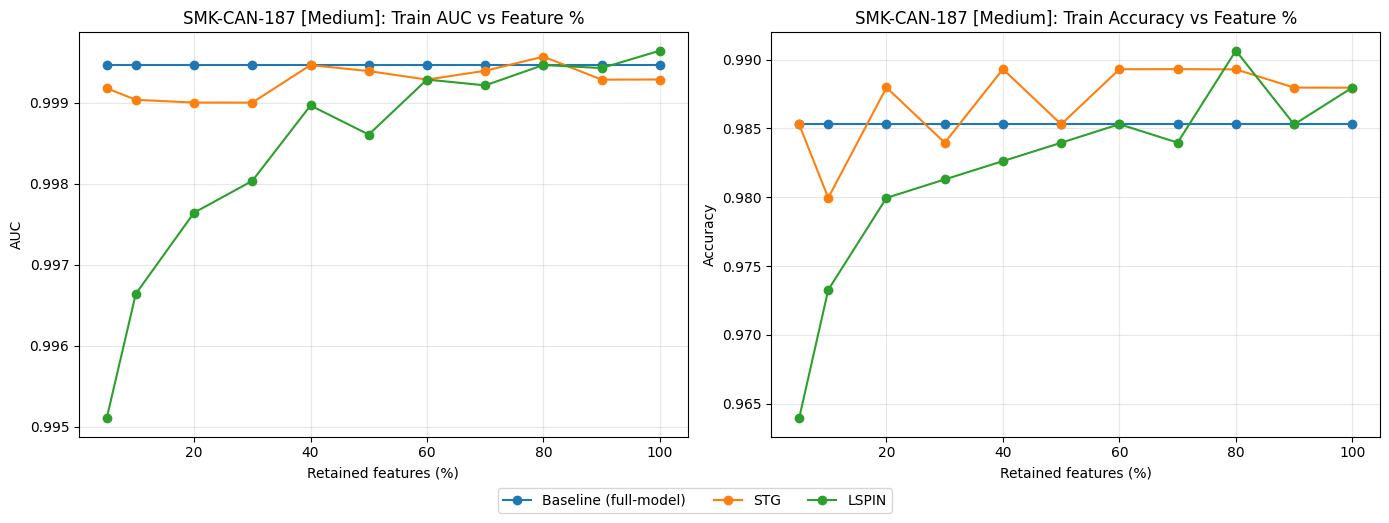

Saved loss plot: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/SMK-CAN-187_train_loss_curve.png


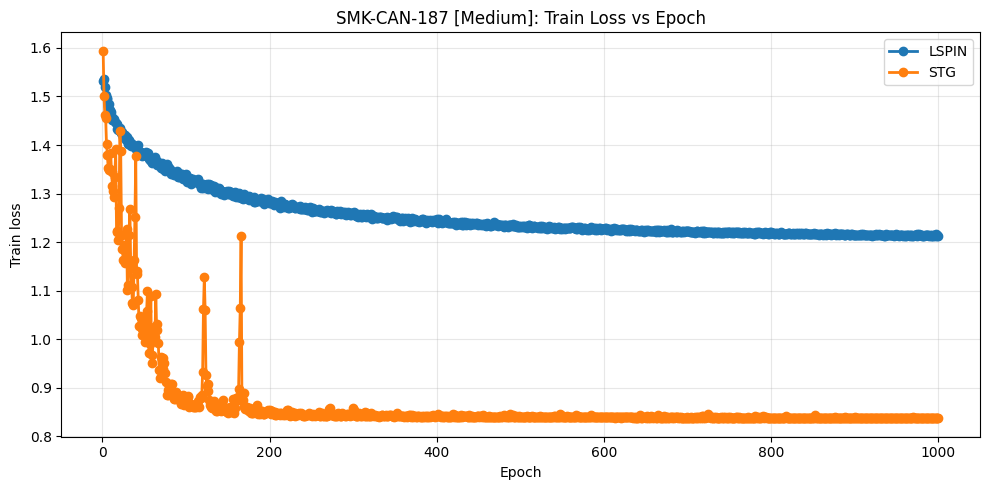

Saved test plot: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/colon_test_curves.png


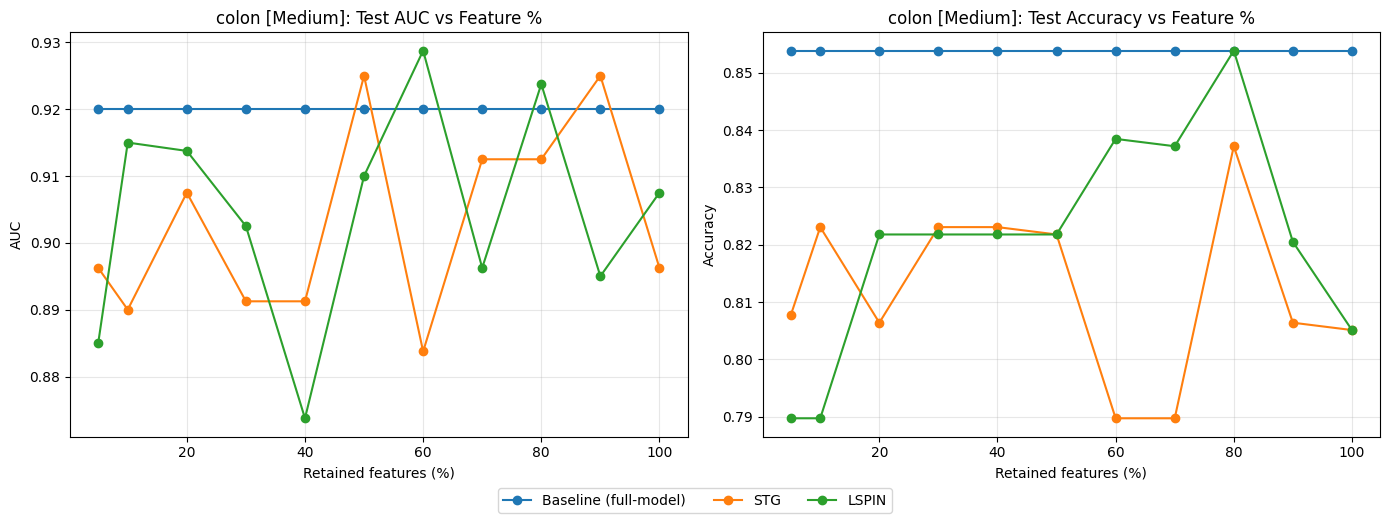

Saved train plot: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/colon_train_curves.png


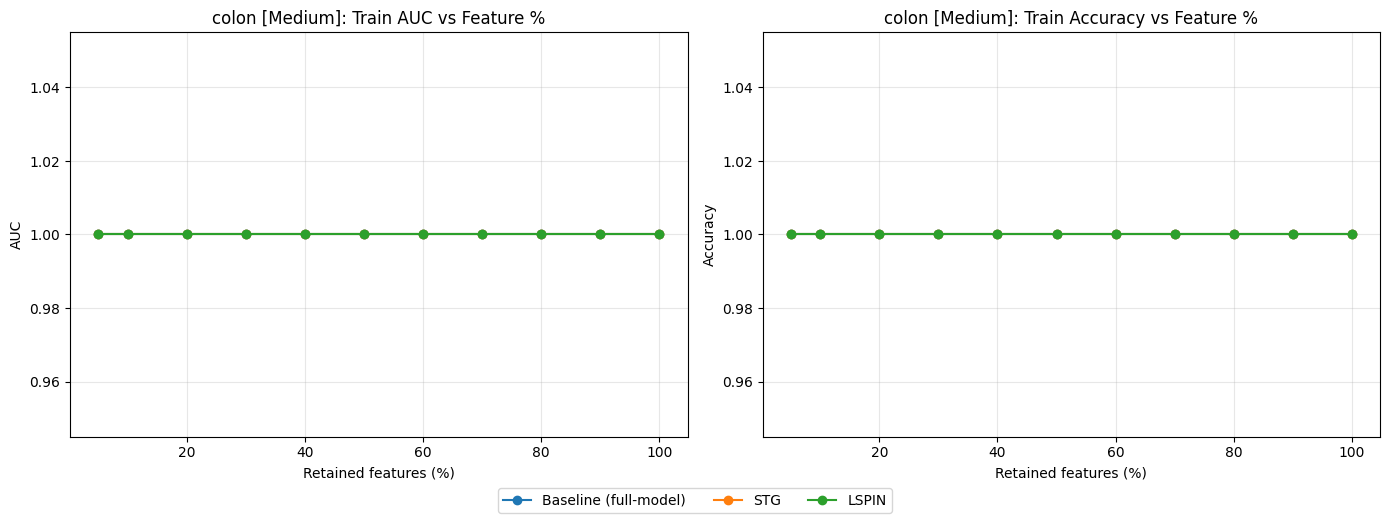

Saved loss plot: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/colon_train_loss_curve.png


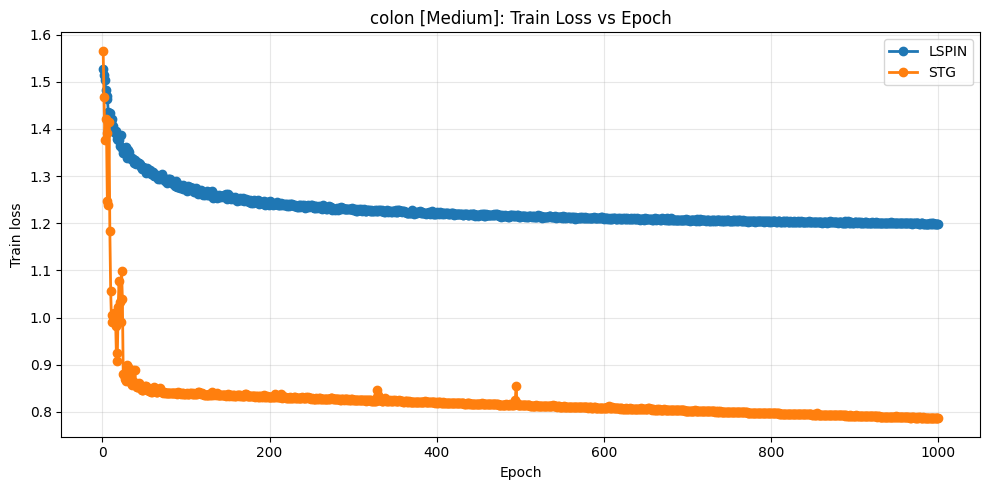

Saved test plot: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/leukemia_test_curves.png


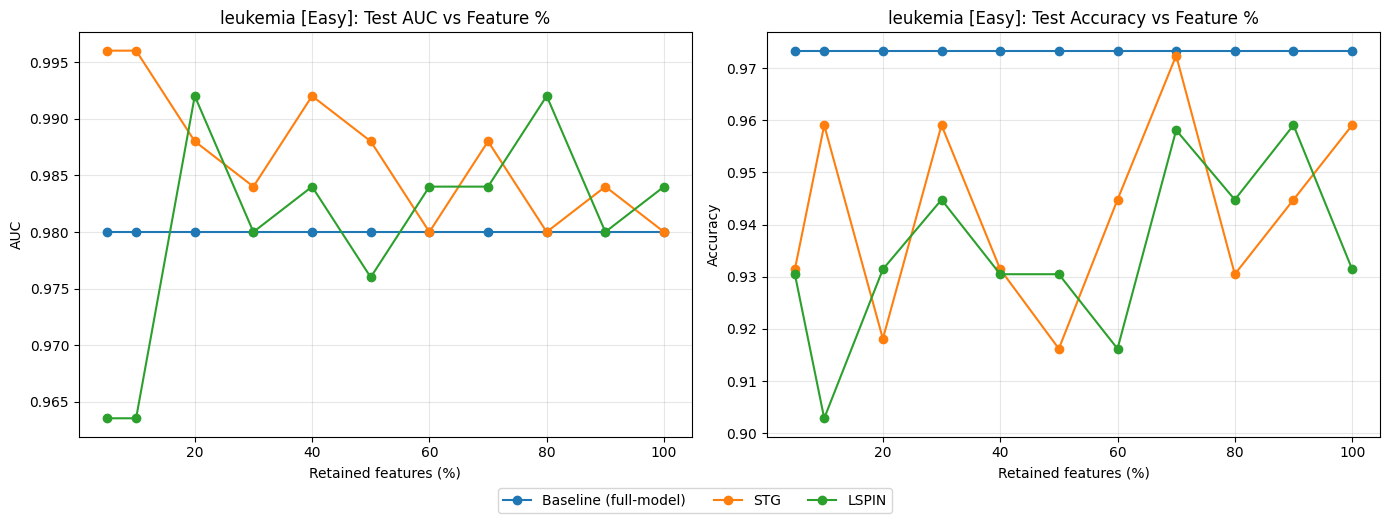

Saved train plot: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/leukemia_train_curves.png


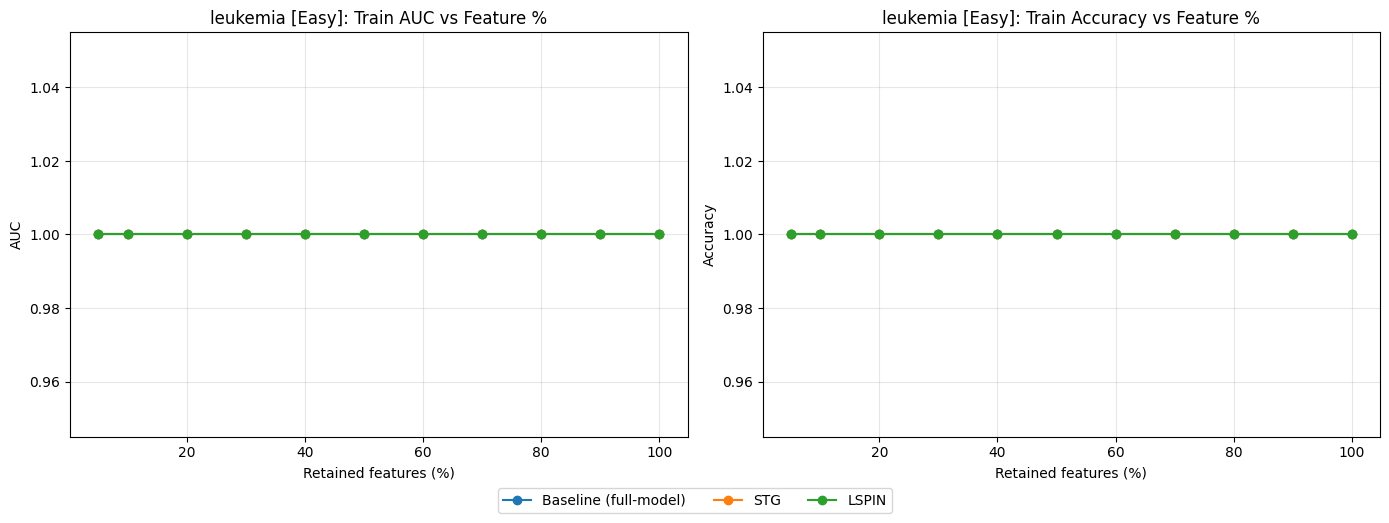

Saved loss plot: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/leukemia_train_loss_curve.png


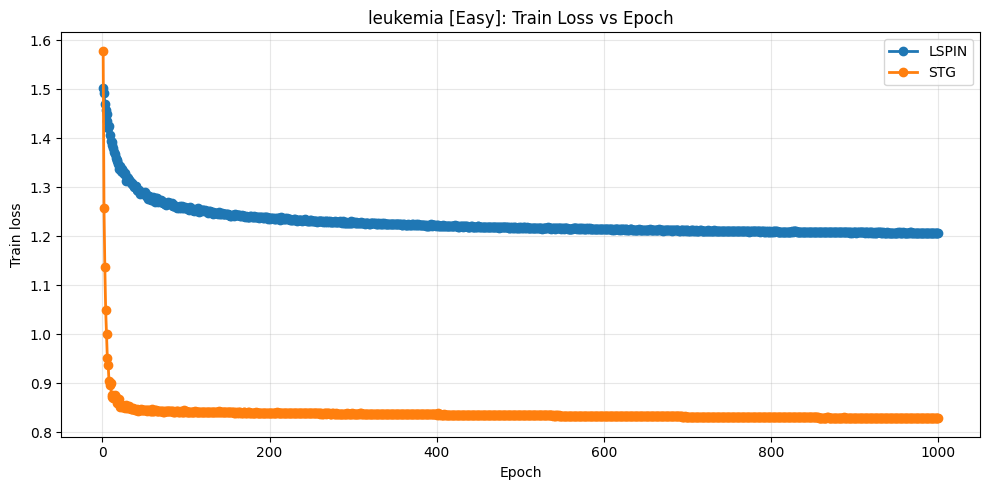

Saved test plot: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/madelon_test_curves.png


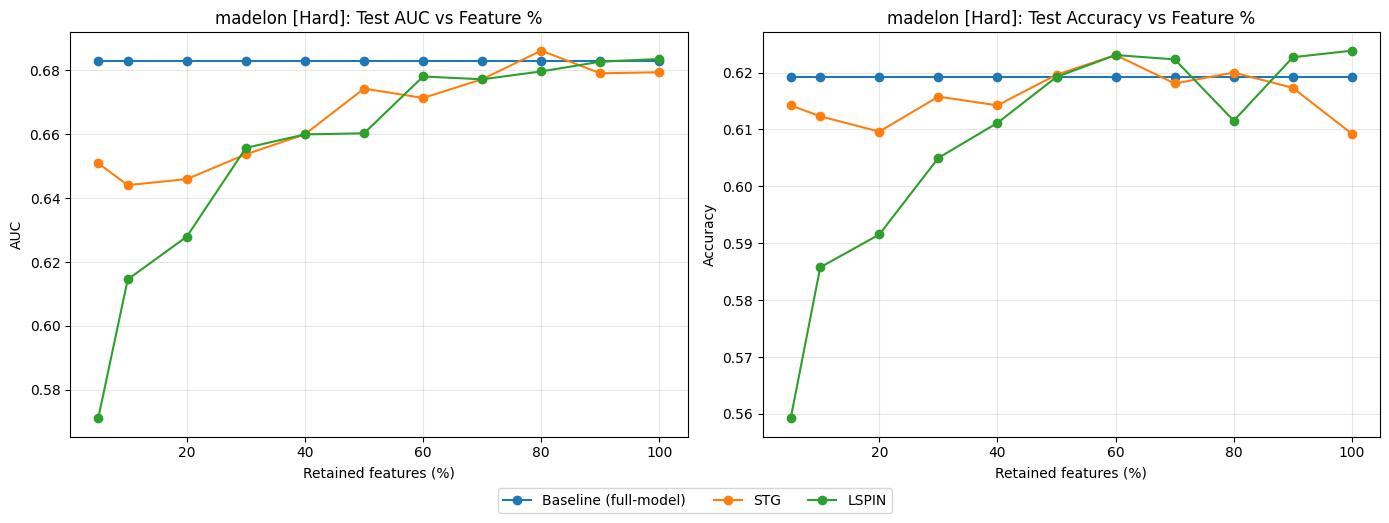

Saved train plot: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/madelon_train_curves.png


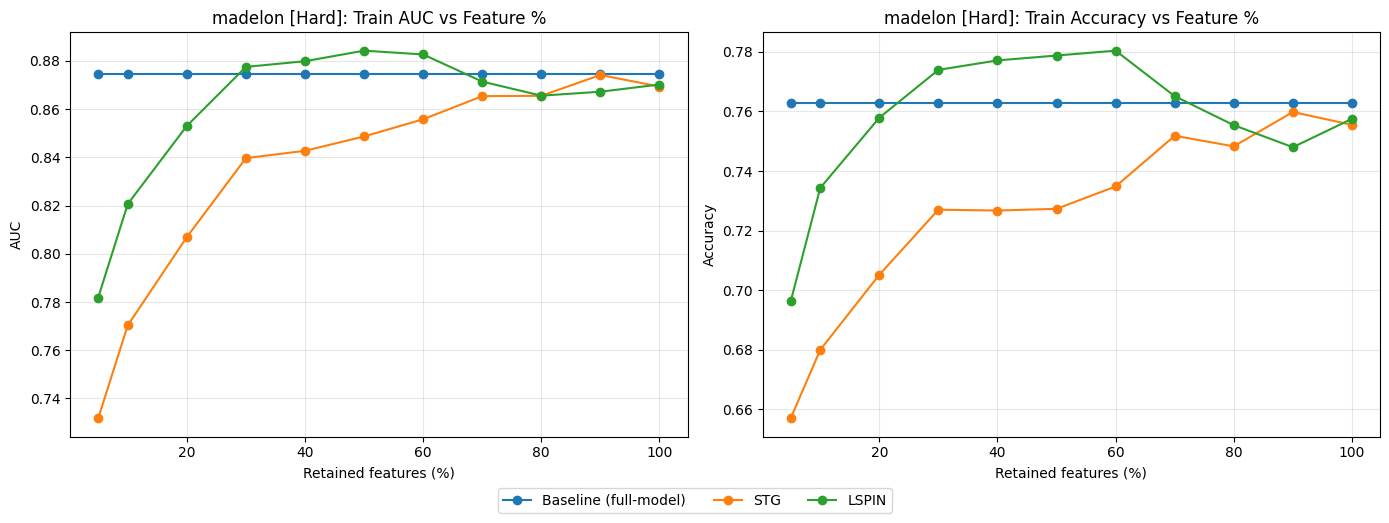

Saved loss plot: /content/drive/MyDrive/Colab Notebooks/Thesis/output/plots/madelon_train_loss_curve.png


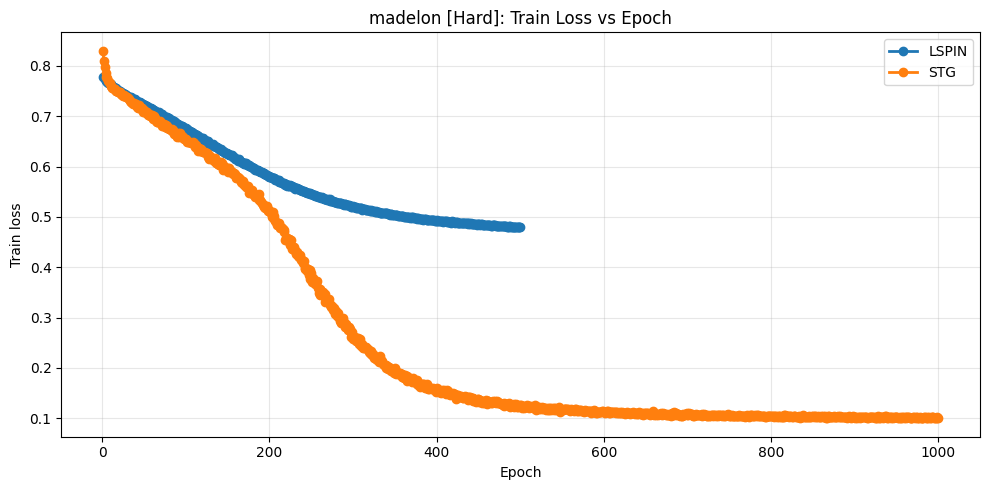

In [11]:
difficulty_by_dataset = {}
for idx, name in enumerate(DEFAULT_DATASET_NAMES):
    if idx < 2:
        difficulty_by_dataset[name] = "Hard"
    elif idx < 4:
        difficulty_by_dataset[name] = "Medium"
    else:
        difficulty_by_dataset[name] = "Easy"

plots_dir = OUTPUT_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

for dataset_name in sorted(combined_summary_df["dataset"].unique()):
    part = combined_summary_df[combined_summary_df["dataset"] == dataset_name].sort_values("feature_pct")
    difficulty = difficulty_by_dataset.get(dataset_name, "Unknown")

    # Test-set curves
    fig_test, axes_test = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

    axes_test[0].plot(part["feature_pct"], part["baseline_auc_mean"], marker="o", label=f"Baseline (full-model)")
    axes_test[0].plot(part["feature_pct"], part["stg_auc_mean"], marker="o", label=f"STG")
    axes_test[0].plot(part["feature_pct"], part["lspin_auc_mean"], marker="o", label=f"LSPIN")
    axes_test[0].set_title(f"{dataset_name} [{difficulty}]: Test AUC vs Feature %")
    axes_test[0].set_xlabel("Retained features (%)")
    axes_test[0].set_ylabel("AUC")
    axes_test[0].grid(True, alpha=0.3)

    axes_test[1].plot(part["feature_pct"], part["baseline_accuracy_mean"], marker="o", label=f"Baseline (full-model)")
    axes_test[1].plot(part["feature_pct"], part["stg_accuracy_mean"], marker="o", label=f"STG")
    axes_test[1].plot(part["feature_pct"], part["lspin_accuracy_mean"], marker="o", label=f"LSPIN")
    axes_test[1].set_title(f"{dataset_name} [{difficulty}]: Test Accuracy vs Feature %")
    axes_test[1].set_xlabel("Retained features (%)")
    axes_test[1].set_ylabel("Accuracy")
    axes_test[1].grid(True, alpha=0.3)

    handles_test, labels_test = axes_test[1].get_legend_handles_labels()
    fig_test.legend(handles_test, labels_test, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))
    fig_test.tight_layout()

    test_plot_path = plots_dir / f"{dataset_name}_test_curves.png"
    fig_test.savefig(test_plot_path, dpi=150, bbox_inches="tight")
    print(f"Saved test plot: {test_plot_path}")
    plt.show()

    # Train-set curves (only if present in summary columns)
    train_cols = {
        "baseline_train_auc_mean", "stg_train_auc_mean", "lspin_train_auc_mean",
        "baseline_train_accuracy_mean", "stg_train_accuracy_mean", "lspin_train_accuracy_mean",
    }
    if train_cols.issubset(part.columns):
        fig_train, axes_train = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

        axes_train[0].plot(part["feature_pct"], part["baseline_train_auc_mean"], marker="o", label=f"Baseline (full-model)")
        axes_train[0].plot(part["feature_pct"], part["stg_train_auc_mean"], marker="o", label=f"STG")
        axes_train[0].plot(part["feature_pct"], part["lspin_train_auc_mean"], marker="o", label=f"LSPIN")
        axes_train[0].set_title(f"{dataset_name} [{difficulty}]: Train AUC vs Feature %")
        axes_train[0].set_xlabel("Retained features (%)")
        axes_train[0].set_ylabel("AUC")
        axes_train[0].grid(True, alpha=0.3)

        axes_train[1].plot(part["feature_pct"], part["baseline_train_accuracy_mean"], marker="o", label=f"Baseline (full-model)")
        axes_train[1].plot(part["feature_pct"], part["stg_train_accuracy_mean"], marker="o", label=f"STG")
        axes_train[1].plot(part["feature_pct"], part["lspin_train_accuracy_mean"], marker="o", label=f"LSPIN")
        axes_train[1].set_title(f"{dataset_name} [{difficulty}]: Train Accuracy vs Feature %")
        axes_train[1].set_xlabel("Retained features (%)")
        axes_train[1].set_ylabel("Accuracy")
        axes_train[1].grid(True, alpha=0.3)

        handles_train, labels_train = axes_train[1].get_legend_handles_labels()
        fig_train.legend(handles_train, labels_train, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))
        fig_train.tight_layout()

        train_plot_path = plots_dir / f"{dataset_name}_train_curves.png"
        fig_train.savefig(train_plot_path, dpi=150, bbox_inches="tight")
        print(f"Saved train plot: {train_plot_path}")
        plt.show()
    else:
        print(f"Train-summary columns are missing for {dataset_name}; skipped train plot.")

    loss_part = combined_loss_df[combined_loss_df["dataset"] == dataset_name].copy()
    if not loss_part.empty:
        loss_summary = (
            loss_part.groupby(["algorithm", "epoch"], as_index=False)["train_loss"]
            .mean()
            .sort_values(["algorithm", "epoch"])
        )
        fig_loss, ax_loss = plt.subplots(figsize=(10, 5))
        for algorithm_name, algo_part in loss_summary.groupby("algorithm"):
            ax_loss.plot(
                algo_part["epoch"],
                algo_part["train_loss"],
                marker="o",
                linewidth=2,
                label=algorithm_name,
            )
        ax_loss.set_title(f"{dataset_name} [{difficulty}]: Train Loss vs Epoch")
        ax_loss.set_xlabel("Epoch")
        ax_loss.set_ylabel("Train loss")
        ax_loss.grid(True, alpha=0.3)
        ax_loss.legend()
        fig_loss.tight_layout()

        loss_plot_path = plots_dir / f"{dataset_name}_train_loss_curve.png"
        fig_loss.savefig(loss_plot_path, dpi=150, bbox_inches="tight")
        print(f"Saved loss plot: {loss_plot_path}")
        plt.show()
    else:
        print(f"Loss history is missing for {dataset_name}; skipped loss plot.")

## Write Outputs to Separate Files

All outputs are written to the output folder. The source ETree file is never modified.

In [12]:
summary_csv = OUTPUT_DIR / "iterative_feature_curve_summary.csv"
fold_csv = OUTPUT_DIR / "iterative_feature_curve_fold_results.csv"
loss_csv = OUTPUT_DIR / "iterative_feature_curve_loss_history.csv"

combined_summary_df.to_csv(summary_csv, index=False)
combined_fold_df.to_csv(fold_csv, index=False)
combined_loss_df.to_csv(loss_csv, index=False)

print("Saved:")
print("-", summary_csv)
print("-", fold_csv)
print("-", loss_csv)

Saved:
- /content/drive/MyDrive/Colab Notebooks/Thesis/output/iterative_feature_curve_summary.csv
- /content/drive/MyDrive/Colab Notebooks/Thesis/output/iterative_feature_curve_fold_results.csv
- /content/drive/MyDrive/Colab Notebooks/Thesis/output/iterative_feature_curve_loss_history.csv


## Repeatable Execution Checks

Run this cell anytime to quickly re-check output artifacts without rerunning model training.

In [13]:
checks = {
    "summary_csv_exists": (OUTPUT_DIR / "iterative_feature_curve_summary.csv").exists(),
    "fold_csv_exists": (OUTPUT_DIR / "iterative_feature_curve_fold_results.csv").exists(),
    "loss_csv_exists": (OUTPUT_DIR / "iterative_feature_curve_loss_history.csv").exists(),
}

check_df = pd.DataFrame([checks])
display(check_df)

if not all(checks.values()):
    raise RuntimeError("One or more repeatability checks failed.")

print("All repeatability checks passed.")

,summary_csv_exists,fold_csv_exists,loss_csv_exists
0,True,True,True


All repeatability checks passed.
